# Image Digit Classification

## Data Processing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

- Reshape 1D arrays into 2D arrays.
- Separate image data and labels into distinct variables (processed_images, labels).

In [2]:
df = pd.read_csv("train_mnist.csv")
processed_images = []
labels = []
columns = df.columns
for index,row in df.iterrows():
    size = 28
    image = []
    label = row["label"]
    for i in range(size):
        image_row = []
        for j in range(size):
            image_row.append(0)
        image.append(image_row)

    for column in columns:
        splited_column = column.split("x")
        if not len(splited_column) == 2:
            continue
        x = int(splited_column[0])-1
        y = int(splited_column[1])-1
        image[x][y] = row[column]

    labels.append(label)
    processed_images.append(image)

Label distribution in the dataset:

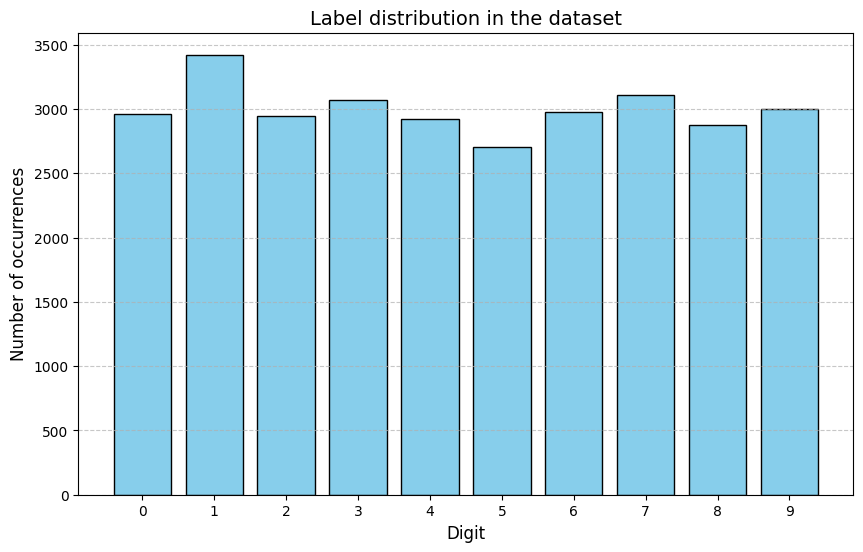

In [3]:
counted_labels = pd.DataFrame(labels).value_counts().sort_index()
plt.figure(figsize=(10, 6))

classes = [str(i[0]) for i in counted_labels.index]
counts = counted_labels.values

plt.bar(classes, counts, color='skyblue', edgecolor='black')

plt.title("Label distribution in the dataset", fontsize=14)
plt.xlabel("Digit", fontsize=12)
plt.ylabel("Number of occurrences", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

- Data Splitting

In [4]:
X = np.array(processed_images)
X = np.expand_dims(X, axis=-1)

y = np.array(labels)

In [5]:
print(f"Images in dataset: {X.shape[0]}")
print(f"shape of each image: {X.shape[1:]}")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

Images in dataset: 30000
shape of each image: (28, 28, 1)


## Images grid for visualization

In [71]:
def show_images_grid(images, labels, rows=4, cols=5):

    num_available = len(images)
    n_to_show = min(num_available, rows * cols)

    plt.figure(figsize=(2 * cols, 2 * rows))

    for i in range(n_to_show):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(labels[i], fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Example

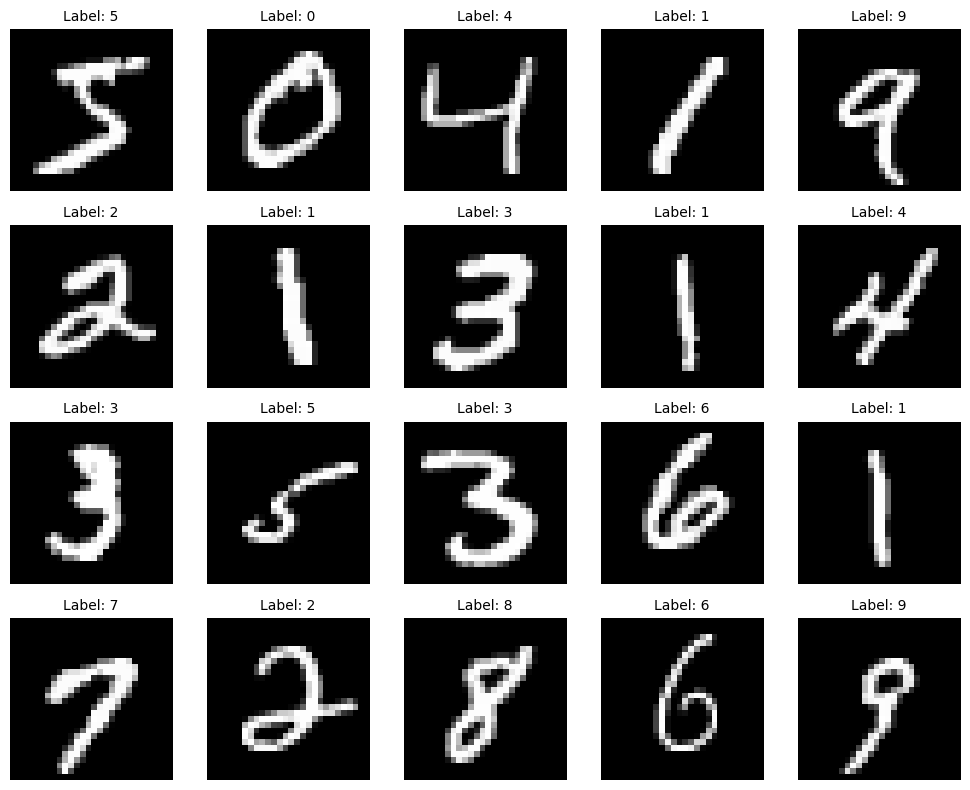

In [139]:
sample = 0

sample_size = 20
labels = y[sample*sample_size:(sample+1)*sample_size]
labels = [f"Label: {labels[i]}" for i in range(len(labels))]

images = processed_images[sample*sample_size:(sample+1)*sample_size ]

show_images_grid(images,labels )

## Augmentation setup

In [24]:
from keras.layers import RandomRotation, RandomTranslation, RandomZoom, Resizing, Rescaling
from keras import Sequential

In [128]:
data_augmentation = Sequential([
    RandomRotation(factor=0.1, fill_mode="constant"),
    RandomTranslation(height_factor=0.1, width_factor=0.1, interpolation='nearest'),
    RandomZoom(height_factor=0.2, width_factor=0.2, interpolation='nearest'),
])

### Augmentation test

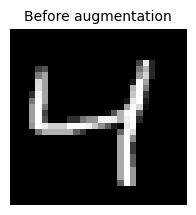

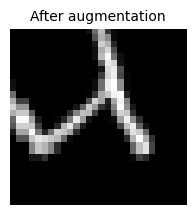

In [135]:
sample = 2

original_image = np.array(processed_images[sample])
original_image = np.expand_dims(original_image, axis=(0, -1))

augmented_image = data_augmentation(original_image, training=True)

show_images_grid(original_image, ["Before augmentation"])
show_images_grid(augmented_image, ["After augmentation"])

## Model Architecture & Hyperparameter Tuning (BayesianOptimization)

In [29]:
from tensorflow.keras import  Input, Model
from tensorflow.keras.layers import BatchNormalization, Activation, Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from keras.regularizers import l1, l2
import keras_tuner as kt

In [30]:
def build_model(hp):
    # ----------------------------------------------------------
    # HyperTuning setup:
    # ----------------------------------------------------------

    n_conv_layers = hp.Int('conv_layers', min_value=1, max_value=3)
    n_layers = hp.Int('dense_layers', min_value=1, max_value=5)
    n_neurons = hp.Int("neurons", min_value = 32, max_value = 450, step = 64)
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.4, step=0.1)

    opt_name = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    cnn_activation_name = hp.Choice("cnn_act", values=["relu", "elu"])
    activation_name = hp.Choice("dense_activation", values=["relu", "elu"])

    if opt_name == 'adam':
        opt = Adam(learning_rate=lr)
    elif opt_name == 'rmsprop':
        opt = RMSprop(learning_rate=lr)
    else:
        opt = SGD(learning_rate=lr)

    # ----------------------------------------------------------
    # Layers:
    # ----------------------------------------------------------

    input_layer = Input(shape=(None, None, 1))
    x = Resizing(height=28, width=28)(input_layer)
    x = Rescaling(scale=1./255)(x)
    x = data_augmentation(x)

    for i in range(n_conv_layers):
        filters = hp.Int(f'filters_{i}',
                     min_value=16 * (2**i),
                     max_value=64 * (2**i),
                     step=16)
        x = Conv2D(filters=filters,
                   kernel_size=(3, 3),
                   strides=(1,1),
                   padding='same'
                   )(x)
        x = BatchNormalization()(x)
        x = Activation(cnn_activation_name)(x)
        x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Flatten()(x)

    for i in range(n_layers):
        reg_type = hp.Choice(f'reg_{i}', values=['l1', 'l2', 'none'])

        if reg_type == 'l1':
            reg = l1(1e-5)
        elif reg_type == 'l2':
            reg = l2(1e-5)
        else:
            reg = None

        x = Dense(n_neurons, kernel_regularizer=reg)(x)
        x = Dropout(dropout_rate)(x)
        x = BatchNormalization()(x)
        x = Activation(activation_name)(x)

    output_layer = Dense(10, activation="softmax")(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=opt,
                    loss="sparse_categorical_crossentropy",
                    metrics=["accuracy"])

    return model

In [31]:
es = EarlyStopping(monitor="val_loss",  patience=15, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [32]:
tuner = kt.BayesianOptimization(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=70,
    directory='tuning_db',
    project_name='digit_recognition',
    overwrite = False
)

Reloading Tuner from tuning_db\digit_recognition\tuner0.json


In [33]:
tuner.search(
    X_train, y_train,
    epochs=200,
    validation_split=0.15,
    callbacks=[es, reduce_lr],
    verbose=2
)

Top 10 best models:

In [34]:
tuner.results_summary()

Results summary
Results in tuning_db\digit_recognition
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 56 summary
Hyperparameters:
conv_layers: 2
dense_layers: 2
neurons: 288
dropout_rate: 0.2
optimizer: adam
learning_rate: 0.01
cnn_act: relu
dense_activation: relu
filters_0: 48
reg_0: l2
filters_1: 112
reg_1: none
reg_2: l2
reg_3: l1
reg_4: l1
filters_2: 112
Score: 0.9924182891845703

Trial 54 summary
Hyperparameters:
conv_layers: 3
dense_layers: 1
neurons: 224
dropout_rate: 0.30000000000000004
optimizer: adam
learning_rate: 0.01
cnn_act: elu
dense_activation: elu
filters_0: 48
reg_0: l2
filters_1: 64
reg_1: none
reg_2: l2
reg_3: l1
reg_4: l2
filters_2: 96
Score: 0.9905882477760315

Trial 55 summary
Hyperparameters:
conv_layers: 3
dense_layers: 1
neurons: 224
dropout_rate: 0.30000000000000004
optimizer: adam
learning_rate: 0.01
cnn_act: relu
dense_activation: relu
filters_0: 48
reg_0: l2
filters_1: 64
reg_1: none
reg_2: none
reg_3: l1
reg_4: l1
filters_2:

### Saving Best model

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.save("saved_model.keras")

## Testing the best model

In [36]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

In [ ]:
model = load_model('saved_model.keras')

In [38]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}%")

141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Accuracy: 98.96%%


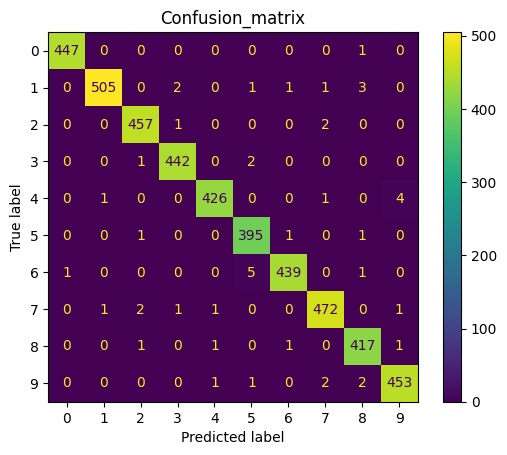

In [39]:
conf_matrix = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = list(range(10)))

cm_display.plot()
plt.title("Confusion_matrix")
plt.grid(False)
plt.show()

### Peek at incorrect predictions
Images are presented in not augmented form.

In [157]:
incorrect_indexes = np.where( y_test != y_pred)
print(f"Incorrect prediction: {len(incorrect_indexes[0])}")

sample = 0
sample_size = 20

y_test_wrong = y_test[incorrect_indexes][sample*sample_size:(sample+1)*sample_size ]
y_pred_wrong = y_pred[incorrect_indexes][sample*sample_size:(sample+1)*sample_size ]
X_test_wrong = X_test[incorrect_indexes][sample*sample_size:(sample+1)*sample_size ]

labels = [f"Label: {y_test_wrong[i]}, Prediction: {y_pred_wrong[i]}" for i in range(sample*sample_size,(sample+1)*sample_size )]

Incorrect prediction: 47


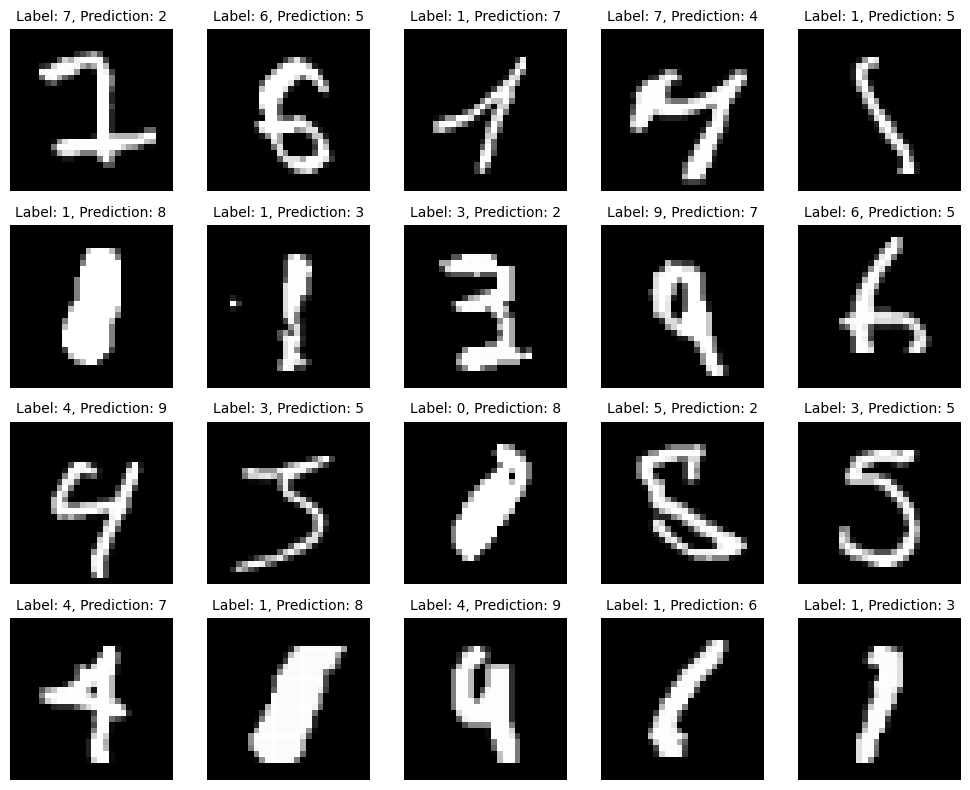

In [158]:
show_images_grid(X_test_wrong, labels)